## Step 1 — Check GPU

#  Deforestation Detection — Phase 1: Train ResNet50 on EuroSAT

In [ ]:
import torch

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device : {device}')
if device == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('No GPU')

Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB


##  Step 2 — Imports

In [ ]:
import torch
import torch.nn as nn
import torchvision
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
import os, time
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print('All imports OK')

All imports OK


##  Step 3 — Config

In [ ]:
DEVICE      = 'cuda' if torch.cuda.is_available() else 'cpu'
BATCH_SIZE  = 64
NUM_EPOCHS  = 15
LR          = 1e-4
NUM_CLASSES = 10
DATA_DIR    = './data'
SAVE_PATH   = './resnet50_eurosat.pth'

CLASS_NAMES = [
    'AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway',
    'Industrial', 'Pasture', 'PermanentCrop', 'Residential',
    'River', 'SeaLake'
]

print(f'Device     : {DEVICE}')
print(f'Batch size : {BATCH_SIZE}')
print(f'Epochs     : {NUM_EPOCHS}')

Device     : cuda
Batch size : 64
Epochs     : 15


##  Step 4 — Load EuroSAT

27,000 Sentinel-2 images, each 64x64px

In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.RandomRotation(90),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print('Downloading EuroSAT...')
full_dataset = datasets.EuroSAT(root=DATA_DIR, download=True, transform=train_transform)
print(f'Total images : {len(full_dataset)}')
print(f'Classes      : {full_dataset.classes}')

n_train = int(0.8 * len(full_dataset))
n_val   = len(full_dataset) - n_train
train_set, val_set = random_split(
    full_dataset, [n_train, n_val],
    generator=torch.Generator().manual_seed(42)
)

# Give val set its own transform (no augmentation)
val_dataset = datasets.EuroSAT(root=DATA_DIR, download=False, transform=val_transform)
val_set = torch.utils.data.Subset(val_dataset, val_set.indices)

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f'Train : {n_train} | Val : {n_val}')

100%|██████████| 94.3M/94.3M [00:01<00:00, 54.8MB/s]


Total images : 27000
Classes      : ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
Train : 21600 | Val : 5400


##  Step 5 — Visualise Samples

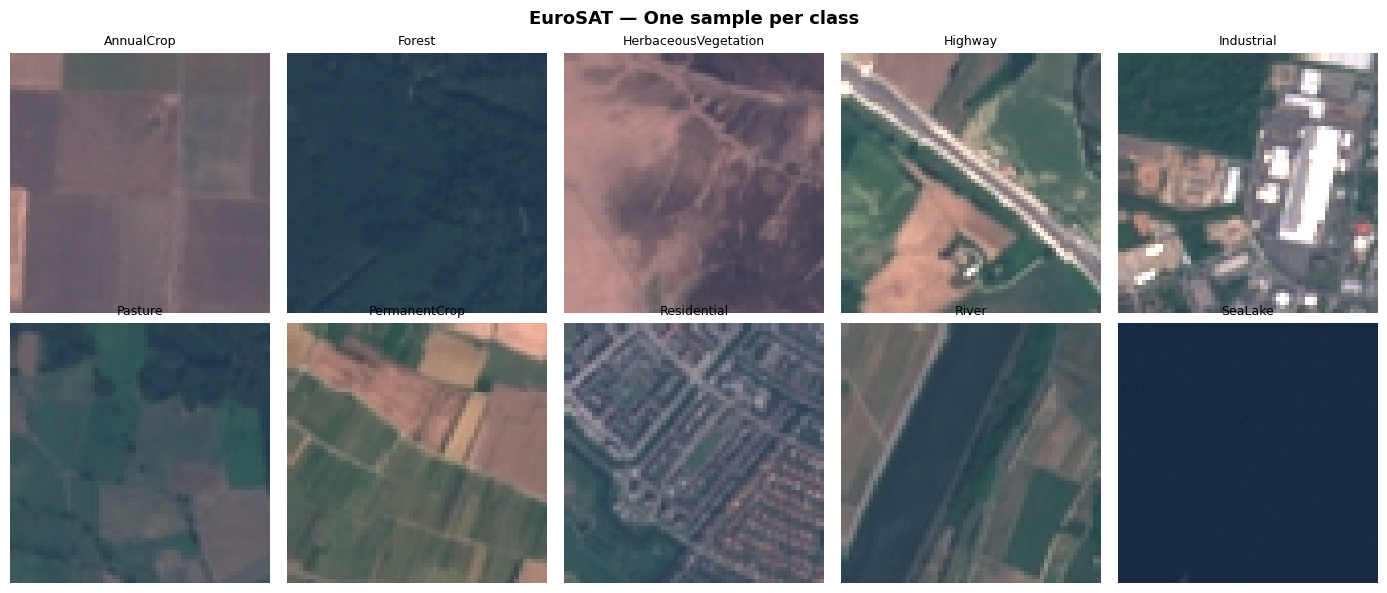

In [ ]:
display_ds = datasets.EuroSAT(
    root=DATA_DIR, download=False,
    transform=transforms.Compose([transforms.Resize((64,64)), transforms.ToTensor()])
)

# Collect one image per class
class_imgs = {}
for img, label in display_ds:
    if label not in class_imgs:
        class_imgs[label] = img
    if len(class_imgs) == NUM_CLASSES:
        break

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle('EuroSAT — One sample per class', fontsize=13, fontweight='bold')
for idx in range(NUM_CLASSES):
    ax = axes[idx // 5][idx % 5]
    ax.imshow(class_imgs[idx].permute(1, 2, 0).clamp(0, 1))
    ax.set_title(CLASS_NAMES[idx], fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.savefig('eurosat_samples.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 6 — Build Model

- `layer1`, `layer2` → frozen (low-level features: edges, textures — already good from ImageNet)
- `layer3`, `layer4` → trainable (will learn satellite-specific patterns)
- `fc` → replaced entirely with a new 10-class head

In [ ]:
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

# Freeze everything
for param in model.parameters():
    param.requires_grad = False

# Unfreeze last 2 residual blocks + FC
for name, param in model.named_parameters():
    if name.startswith(('layer3', 'layer4', 'fc')):
        param.requires_grad = True

# New classification head
model.fc = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(2048, 512),
    nn.ReLU(),
    nn.Dropout(p=0.2),
    nn.Linear(512, NUM_CLASSES)
)
model = model.to(DEVICE)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'Total params     : {total:,}')
print(f'Trainable params : {trainable:,}  ({100*trainable/total:.1f}%)')
print(f'Frozen params    : {total-trainable:,}  ({100*(total-trainable)/total:.1f}%)')

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 212MB/s]


Total params     : 24,562,250
Trainable params : 23,117,322  (94.1%)
Frozen params    : 1,444,928  (5.9%)


## Step 7 — Train

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR, weight_decay=1e-4
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_acc = 0.0
total_start  = time.time()

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()

    # Train
    model.train()
    t_loss, t_correct = 0.0, 0
    for imgs, labels in tqdm(train_loader, desc=f'Epoch {epoch:02d}/{NUM_EPOCHS} Train', leave=False):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        out  = model(imgs)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        t_loss    += loss.item() * imgs.size(0)
        t_correct += (out.argmax(1) == labels).sum().item()
    scheduler.step()

    # Validate
    model.eval()
    v_loss, v_correct = 0.0, 0
    with torch.no_grad():
        for imgs, labels in tqdm(val_loader, desc=f'Epoch {epoch:02d}/{NUM_EPOCHS} Val  ', leave=False):
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            out  = model(imgs)
            loss = criterion(out, labels)
            v_loss    += loss.item() * imgs.size(0)
            v_correct += (out.argmax(1) == labels).sum().item()

    ta = t_correct / n_train
    va = v_correct / n_val
    history['train_loss'].append(t_loss / n_train)
    history['val_loss'].append(v_loss / n_val)
    history['train_acc'].append(ta)
    history['val_acc'].append(va)

    tag = ''
    if va > best_val_acc:
        best_val_acc = va
        torch.save(model.state_dict(), SAVE_PATH)
        tag = '  <- best saved'

    print(f'Epoch {epoch:02d}/{NUM_EPOCHS}  '
          f'Train {ta:.4f}  Val {va:.4f}  '
          f'[{time.time()-t0:.0f}s]{tag}')

print(f'Done in {(time.time()-total_start)/60:.1f} min')
print(f'Best val accuracy: {best_val_acc*100:.2f}%')

Epoch 01/15  Train 0.8568  Val 0.9380  [37s]  <- best saved


Epoch 02/15  Train 0.9324  Val 0.9520  [33s]  <- best saved


Epoch 03/15  Train 0.9460  Val 0.9580  [32s]  <- best saved


Epoch 04/15  Train 0.9508  Val 0.9567  [32s]


Epoch 05/15  Train 0.9576  Val 0.9669  [31s]  <- best saved


...

Epoch 11/15  Train 0.9786  Val 0.9778  [33s]  <- best saved


Epoch 12/15  Train 0.9812  Val 0.9794  [32s]  <- best saved


Epoch 13/15  Train 0.9831  Val 0.9791  [31s]


Epoch 14/15  Train 0.9839  Val 0.9791  [32s]


Epoch 15/15  Train 0.9846  Val 0.9789  [31s]
Done in 8.0 min
Best val accuracy: 97.94%


##  Step 8 — Training Curves

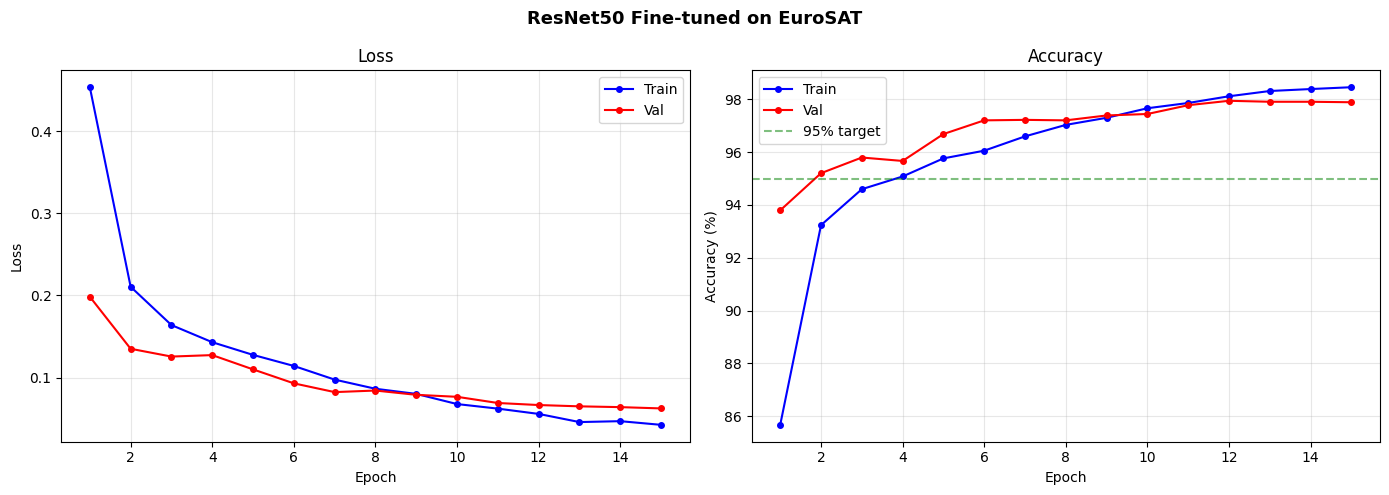

Saved: training_curves.png


In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('ResNet50 Fine-tuned on EuroSAT', fontsize=13, fontweight='bold')
ep = range(1, NUM_EPOCHS + 1)

ax1.plot(ep, history['train_loss'], 'b-o', markersize=4, label='Train')
ax1.plot(ep, history['val_loss'],   'r-o', markersize=4, label='Val')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('Loss'); ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(ep, [a*100 for a in history['train_acc']], 'b-o', markersize=4, label='Train')
ax2.plot(ep, [a*100 for a in history['val_acc']],   'r-o', markersize=4, label='Val')
ax2.axhline(95, color='green', linestyle='--', alpha=0.5, label='95% target')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Accuracy'); ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: training_curves.png')

##  Step 9 — Confusion Matrix

See which land types the model sometimes confuses.

Evaluating: 100%|██████████| 85/85 [00:03<00:00, 25.82it/s]


                      precision    recall  f1-score   support

          AnnualCrop       0.98      0.97      0.98       631
              Forest       0.99      0.99      0.99       582
HerbaceousVegetation       0.96      0.98      0.97       612
             Highway       0.97      0.97      0.97       525
          Industrial       0.99      0.98      0.98       484
             Pasture       0.96      0.97      0.97       396
       PermanentCrop       0.98      0.96      0.97       506
         Residential       1.00      0.98      0.99       606
               River       0.98      0.97      0.98       497
             SeaLake       0.99      1.00      0.99       561

            accuracy                           0.98      5400
           macro avg       0.98      0.98      0.98      5400
        weighted avg       0.98      0.98      0.98      5400



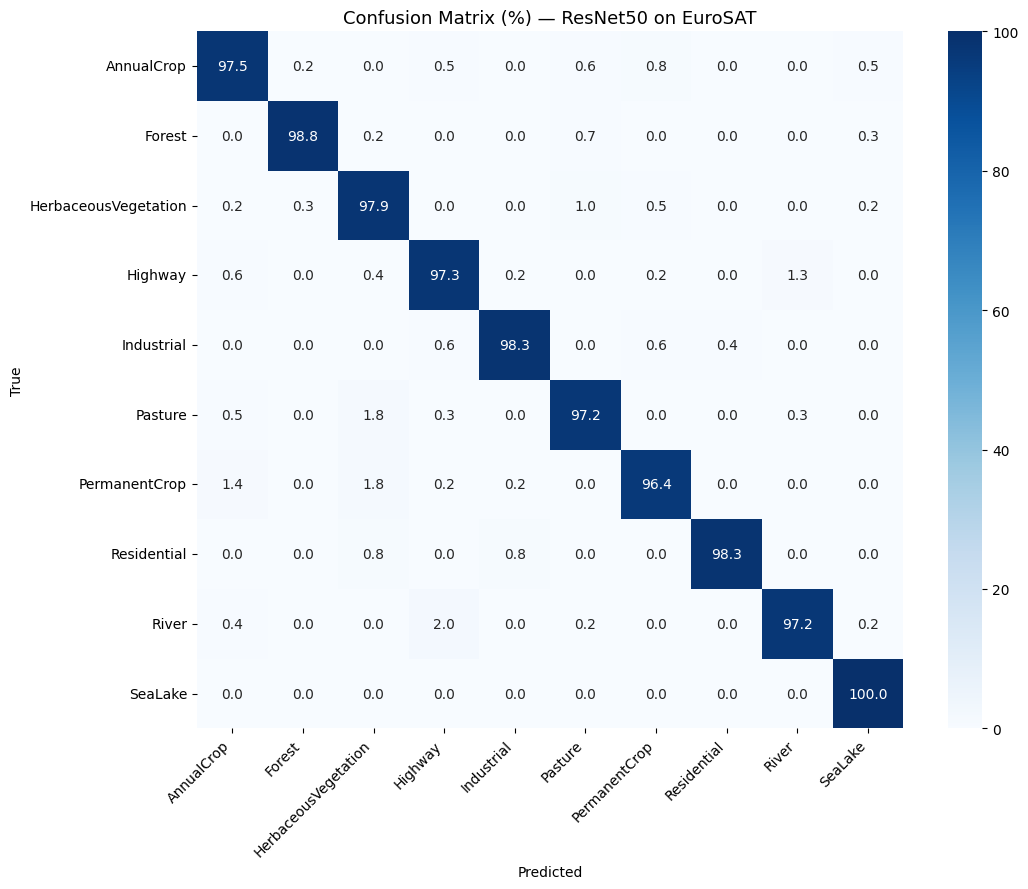

Saved: confusion_matrix.png


In [ ]:
model.load_state_dict(torch.load(SAVE_PATH, map_location=DEVICE))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in tqdm(val_loader, desc='Evaluating'):
        preds = model(imgs.to(DEVICE)).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

cm = confusion_matrix(all_labels, all_preds)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

plt.figure(figsize=(11, 9))
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix (%) — ResNet50 on EuroSAT', fontsize=13)
plt.ylabel('True'); plt.xlabel('Predicted')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: confusion_matrix.png')

In [ ]:
from google.colab import files
for f in ['resnet50_eurosat.pth', 'training_curves.png',
           'confusion_matrix.png', 'eurosat_samples.png']:
    files.download(f)
    print(f'Downloaded: {f}')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: resnet50_eurosat.pth


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Downloaded: confusion_matrix.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: eurosat_samples.png
